# Emergency Room Triage Prediction  
## Stage 1 — Project Definition, Dataset, Cleaning, and EDA

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("../data/synthetic_medical_triage.csv")
df.head()


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level (how urgent) 0 not really &3 very urgent,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0,NaN,NaN,NaN
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3,NaN,NaN,NaN
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1,NaN,NaN,NaN
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1,NaN,NaN,NaN
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0,NaN,NaN,NaN


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 13 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   age                                                     18000 non-null  float64
 1   heart_rate                                              18000 non-null  float64
 2   systolic_blood_pressure                                 18000 non-null  float64
 3   oxygen_saturation                                       18000 non-null  float64
 4   body_temperature                                        18000 non-null  float64
 5   pain_level                                              18000 non-null  int64  
 6   chronic_disease_count                                   18000 non-null  int64  
 7   previous_er_visits                                      18000 non-null  int64  
 8   arrival_mode                                   

In [8]:
df.head()


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level (how urgent) 0 not really &3 very urgent,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0,NaN,NaN,NaN
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3,NaN,NaN,NaN
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1,NaN,NaN,NaN
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1,NaN,NaN,NaN
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0,NaN,NaN,NaN


### Initial Observations
- Dataset has **18,000 rows** and **13 columns**.
- Three columns (`Unnamed: 10`, `Unnamed: 11`, `Unnamed: 12`) contain only missing values.
- Target column name is long and needs renaming.
- No missing values in main clinical features.

## Data Cleaning

In [9]:
df = df.drop(columns=["Unnamed: 10", "Unnamed: 11", "Unnamed: 12"])

In [10]:
df = df.rename(columns={
    "triage_level  (how urgent) 0 not really &3 very urgent": "triage_level"
})


In [11]:
df = df.drop_duplicates()


In [12]:
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      18000 non-null  float64
 1   heart_rate               18000 non-null  float64
 2   systolic_blood_pressure  18000 non-null  float64
 3   oxygen_saturation        18000 non-null  float64
 4   body_temperature         18000 non-null  float64
 5   pain_level               18000 non-null  int64  
 6   chronic_disease_count    18000 non-null  int64  
 7   previous_er_visits       18000 non-null  int64  
 8   arrival_mode             18000 non-null  str    
 9   triage_level             18000 non-null  int64  
dtypes: float64(5), int64(4), str(1)
memory usage: 1.4 MB


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0


In [13]:
df.isnull().sum()


age                        0
heart_rate                 0
systolic_blood_pressure    0
oxygen_saturation          0
body_temperature           0
pain_level                 0
chronic_disease_count      0
previous_er_visits         0
arrival_mode               0
triage_level               0
dtype: int64

In [14]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


### Validation Summary
- All unnecessary columns removed  
- Target column renamed  
- No duplicates remain  
- Dataset is clean and ready for EDA  


## Exploratory Data Analysis ( EDA )

In [15]:
df["triage_level"].value_counts()


triage_level
0    9924
1    4484
2    2701
3     891
Name: count, dtype: int64

C:\Users\talah\AppData\Local\Temp\ipykernel_27216\934425015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["triage_level"], palette="viridis")


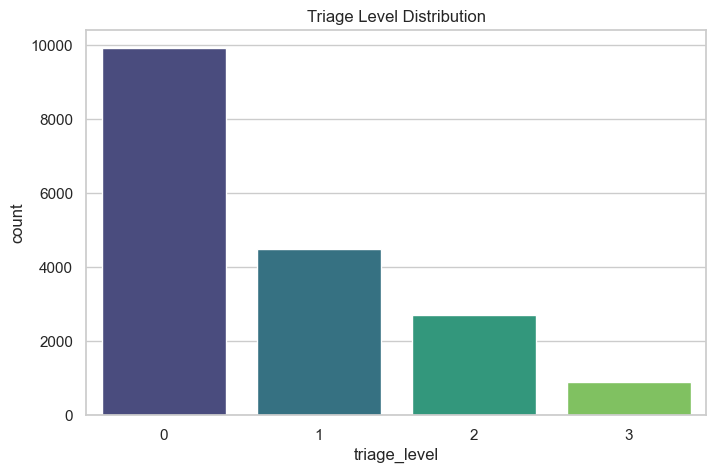

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["triage_level"], palette="viridis")
plt.title("Triage Level Distribution")
plt.show()


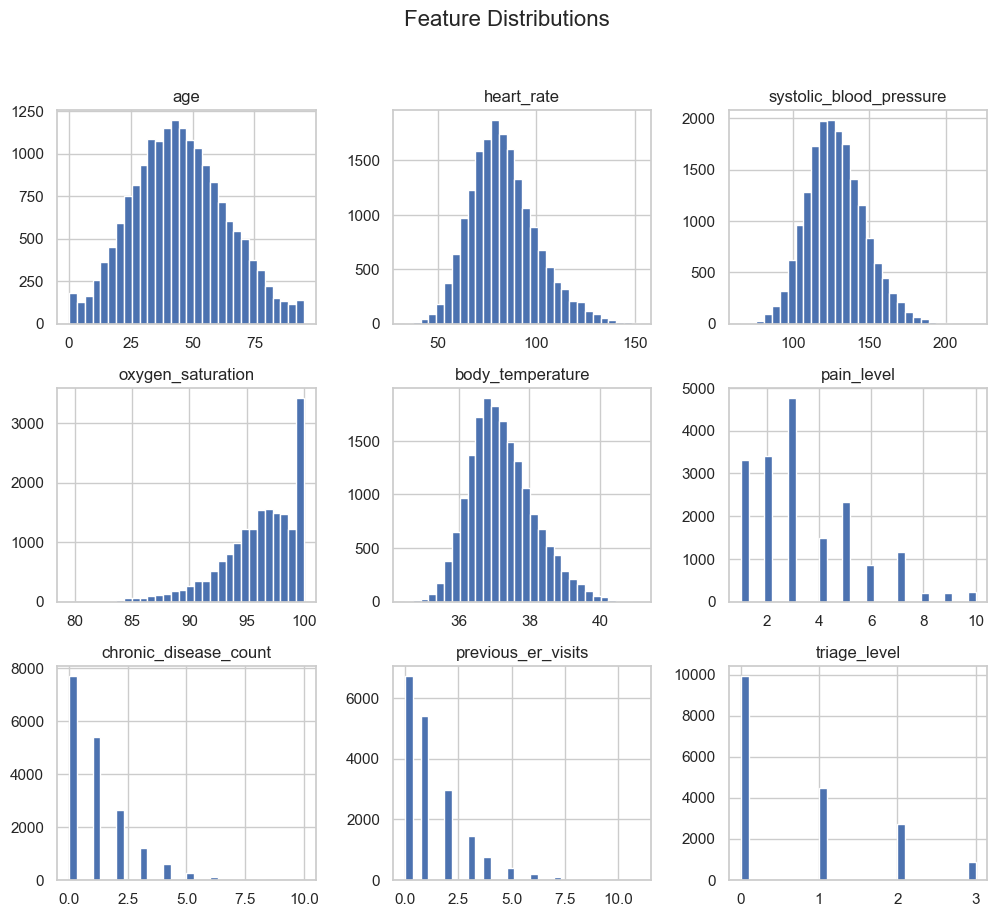

In [17]:
df.hist(figsize=(12,10), bins=30, color="#4C72B0")
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


In [20]:
df["arrival_mode_encoded"] = df["arrival_mode"].map({
    "walk_in": 0,
    "ambulance": 1
})



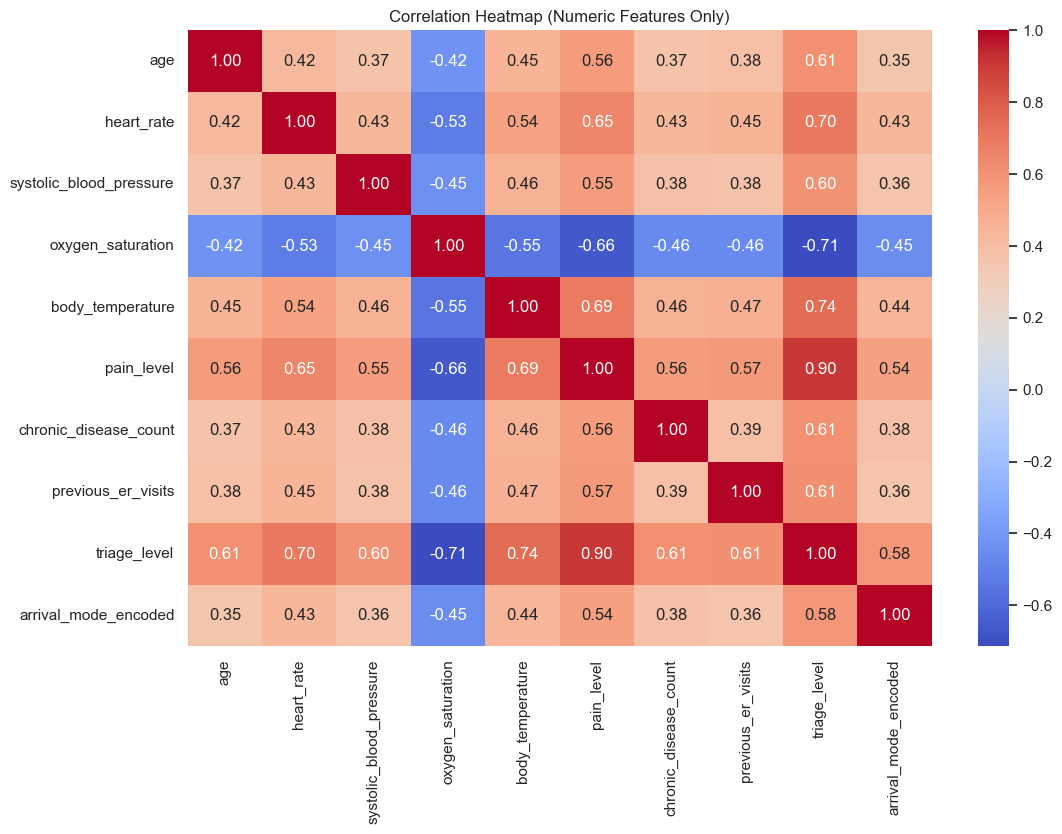

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()



C:\Users\talah\AppData\Local\Temp\ipykernel_27216\3976745830.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["arrival_mode"], palette="Set2")


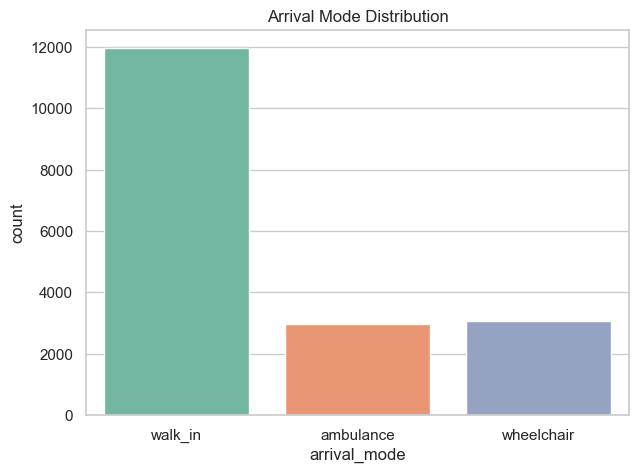

In [23]:
plt.figure(figsize=(7,5))
sns.countplot(x=df["arrival_mode"], palette="Set2")
plt.title("Arrival Mode Distribution")
plt.show()


## EDA Summary
Triage levels are imbalanced, with Level 0 being the most common and Level 3 the least frequent.

Vital signs (heart rate, blood pressure, oxygen saturation, temperature) show realistic medical ranges with no extreme outliers.

Pain level and chronic disease count show wide variation, indicating diverse patient conditions.

Arrival mode is mostly "walk_in", with fewer ambulance and wheelchair arrivals.

Correlation analysis shows:

Pain level strongly correlates with triage level (higher pain → higher urgency).

Oxygen saturation negatively correlates with triage level (lower oxygen → higher urgency).

Other vitals show expected medical relationships.

The dataset is now clean, consistent, and ready for:

Feature engineering

Model development

Handling class imbalance